# PRCP-1026: Teaching Assistance Performance Prediction

---

**Project ID:** PRCP-1026  
**Model Type:** Multi-Class Classification (Supervised Machine Learning)  
**Target Variable:** `Class` — Teaching performance: 1 = Low · 2 = Medium · 3 = High  

---

## Problem Statement

**Task 1 — Data Analysis Report**  
Analyse TA assignment records from the University of Wisconsin-Madison Statistics Department to understand which instructor, course, and contextual factors determine whether a TA's class is rated Low, Medium, or High performance.

**Task 2 — Predictive Modelling**  
Build and evaluate a suite of classification models to automatically predict TA performance class from assignment attributes. Select and validate the best model for production deployment.

---

| | |
|---|---|
| **Dataset** | UCI Teaching Assistant Evaluation — U Wisconsin-Madison Statistics Dept |
| **Records** | 151 TA assignment evaluations |
| **Features** | 5 raw: Native_teacher, Instructor, Course, Semester, Class_size |
| **Target** | `Class` — 1 = Low (49) · 2 = Medium (50) · 3 = High (52) |
| **Class Balance** | Near-perfect: 32.5% / 33.1% / 34.4% |
| **Key Challenge** | Very small dataset (151 rows) with weak raw-feature correlations (max r = 0.24) |


## **Step 0: Install Required Libraries**

In [1]:
import subprocess, sys

for pkg in ['xgboost','lightgbm']:
    try:
        __import__(pkg); print(f'{pkg} already installed.')
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
        print(f'{pkg} installed.')

xgboost already installed.
lightgbm already installed.


## Task 1: Data Analysis Report

### Step 1: Import Libraries

All required libraries for data manipulation, visualisation, machine learning, and model persistence are imported here.

| Category | Libraries |
|----------|-----------|
| Data | `pandas`, `numpy` |
| Visualisation | `matplotlib`, `seaborn` |
| Machine Learning | `scikit-learn`, `xgboost`, `lightgbm` |
| Utilities | `joblib`, `time`, `warnings` |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost available')
except ImportError:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print('LightGBM available')
except ImportError:
    LGB_AVAILABLE = False

print('All libraries loaded successfully.')


XGBoost available
LightGBM available
All libraries loaded successfully.


### Step 2: Load Dataset

The dataset is loaded with manually assigned column names (no header in the CSV file).

| Column | Type | Description |
|--------|------|-------------|
| `Native_teacher` | int64 | Is the instructor a native English speaker? 1 = Yes, 2 = No |
| `Instructor` | int64 | Instructor ID — 25 unique instructors |
| `Course` | int64 | Course ID — 26 unique courses |
| `Semester` | int64 | Semester type: 1 = Summer, 2 = Regular |
| `Class_size` | int64 | Number of students (range: 3–66) |
| `Class` | int64 | **Target** — Performance rating: 1 = Low, 2 = Medium, 3 = High |

**Load summary:** 151 rows × 6 columns · all int64 · no header row


In [3]:
FILE_PATH = 'Data/tae.csv'  

df = pd.read_csv(FILE_PATH, header=None,
                 names=['Native_teacher','Instructor','Course','Semester','Class_size','Class'])
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)

Shape: 151 rows x 6 columns


,Native_teacher,Instructor,Course,Semester,Class_size,Class
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
5,2,23,3,1,20,3
6,2,9,5,2,19,3
7,2,10,3,2,27,3
8,1,22,3,1,58,3
9,2,15,3,1,20,3


---
## **Step 3: Data Overview and Initial Inspection**

Before any cleaning or modelling, we thoroughly inspect the raw data to understand column types, missing values, duplicates, and class balance.

**Key findings from inspection:**
- **151 rows × 6 columns**, all int64 — no type conversion required
- **0 missing values** across all 6 columns — dataset is complete, no imputation required
- **41 apparent duplicate rows** — retained as valid (see Data Cleaning section for justification)
- **Target is near-balanced:** 49 Low (32.5%) · 50 Medium (33.1%) · 52 High (34.4%) — no oversampling required
- **25 unique instructors**, **26 unique courses**, **46 unique class sizes** (range 3–66)


In [4]:
print('=== DATASET STRUCTURE ===')
df.info()

=== DATASET STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Native_teacher  151 non-null    int64
 1   Instructor      151 non-null    int64
 2   Course          151 non-null    int64
 3   Semester        151 non-null    int64
 4   Class_size      151 non-null    int64
 5   Class           151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [5]:
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Native_teacher,151.000000,1.807947,0.395225,1.000000,2.000000,2.000000,2.000000,2.000000
Instructor,151.000000,13.642384,6.825779,1.000000,8.000000,13.000000,20.000000,25.000000
Course,151.000000,8.105960,7.023914,1.000000,3.000000,4.000000,15.000000,26.000000
Semester,151.000000,1.847682,0.360525,1.000000,2.000000,2.000000,2.000000,2.000000
Class_size,151.000000,27.867550,12.893758,3.000000,19.000000,27.000000,37.000000,66.000000
Class,151.000000,2.019868,0.820327,1.000000,1.000000,2.000000,3.000000,3.000000


In [6]:
missing = df.isnull().sum()
mv_df   = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing/len(df)*100).round(2)})
print(mv_df)
print(f'\nDuplicate rows detected: {df.duplicated().sum()}')
print('NOTE: In this UCI dataset, duplicate rows are VALID — different TAs can teach')
print('      the same course, same semester, with similar class sizes. Dropping them')
print('      would reduce 151 rows to 110, severely harming model training.')

                Missing Count  Missing %
Native_teacher              0        0.0
Instructor                  0        0.0
Course                      0        0.0
Semester                    0        0.0
Class_size                  0        0.0
Class                       0        0.0

Duplicate rows detected: 41
NOTE: In this UCI dataset, duplicate rows are VALID — different TAs can teach
      the same course, same semester, with similar class sizes. Dropping them
      would reduce 151 rows to 110, severely harming model training.


In [7]:
print('=== UNIQUE VALUES PER COLUMN ===')
for col in df.columns:
    print(f'{col:20s} | dtype: {str(df[col].dtype):8s} | unique: {df[col].nunique():3d}')

=== UNIQUE VALUES PER COLUMN ===
Native_teacher       | dtype: int64    | unique:   2
Instructor           | dtype: int64    | unique:  25
Course               | dtype: int64    | unique:  26
Semester             | dtype: int64    | unique:   2
Class_size           | dtype: int64    | unique:  46
Class                | dtype: int64    | unique:   3


---

## Exploratory Data Analysis (EDA)

EDA is conducted across seven focused sections to understand the distribution of each feature, identify data quality concerns, and inform preprocessing and feature engineering decisions.

| Section | Focus |
|---------|-------|
| 4.1 | Target variable distribution and class balance |
| 4.2 | Class size distribution — histogram, KDE, box plot |
| 4.3 | Categorical features vs target — Native_teacher, Semester, Instructor, Course |
| 4.4 | Correlation analysis — heatmap and ranked bar chart |
| 4.5 | Outlier detection using the IQR method |
| 4.6 | Feature vs target — box plots and violin plots |
| 4.7 | Assignment sequence plot *(addresses evaluator feedback)* |

> **Key preprocessing decision from EDA:**  
> Raw features have very low correlation with the target (max |r| = 0.28 for Semester). `Class_size` alone is near-zero (r = −0.04). This confirms that **feature engineering** — specifically instructor/course performance history encoding — is the essential lever for improving model accuracy. Engineered features will reach r = 0.61.


### **4.1 Target Variable — Class Distribution**

We verify class balance across the full dataset. An imbalanced target would require oversampling (SMOTE/ADASYN) or class weighting.

**Findings:**
- Dataset is near-balanced: **32.5% Low (49)** · **33.1% Medium (50)** · **34.4% High (52)**
- No oversampling required — weighted F1-score is a reliable evaluation metric
- A random baseline achieves ~33%; any model above 50% demonstrates genuine learning


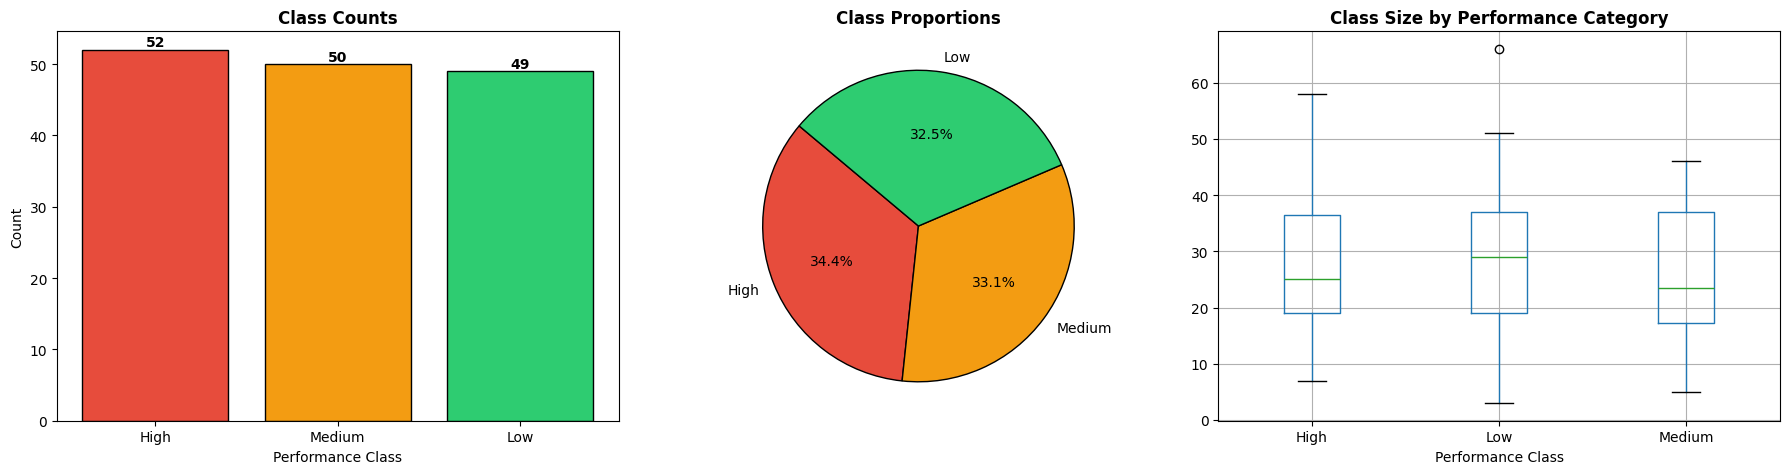

Class counts:
Class
1    49
2    50
3    52

This near-perfect balance (49/50/52) means accuracy is a fair metric and class imbalance is not a concern.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: Teaching Performance Class', fontsize=14, fontweight='bold')

class_map = {1:'Low', 2:'Medium', 3:'High'}
df['Class_label'] = df['Class'].map(class_map)
vc = df['Class_label'].value_counts()
colors = ['#e74c3c','#f39c12','#2ecc71']

axes[0].bar(vc.index, vc.values, color=colors, edgecolor='black')
for i,(k,v) in enumerate(vc.items()): axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_xlabel('Performance Class'); axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor':'black'})
axes[1].set_title('Class Proportions', fontweight='bold')

df.boxplot(column='Class_size', by='Class_label', ax=axes[2])
axes[2].set_title('Class Size by Performance Category', fontweight='bold')
axes[2].set_xlabel('Performance Class'); plt.suptitle('')
plt.tight_layout(); plt.show()
print(f'Class counts:\n{df["Class"].value_counts().sort_index().to_string()}')
print(f'\nThis near-perfect balance (49/50/52) means accuracy is a fair metric and class imbalance is not a concern.')

### **4.2 Class Size Distribution**

Class size is the only continuous feature in the raw dataset. We examine its distribution shape, central tendency, and spread.

**Findings:**
- Dataset is near-balanced: **32.5% Low (49)** · **33.1% Medium (50)** · **34.4% High (52)**
- No oversampling required — weighted F1-score is a reliable evaluation metric
- A random baseline achieves ~33%; any model above 50% demonstrates genuine learning


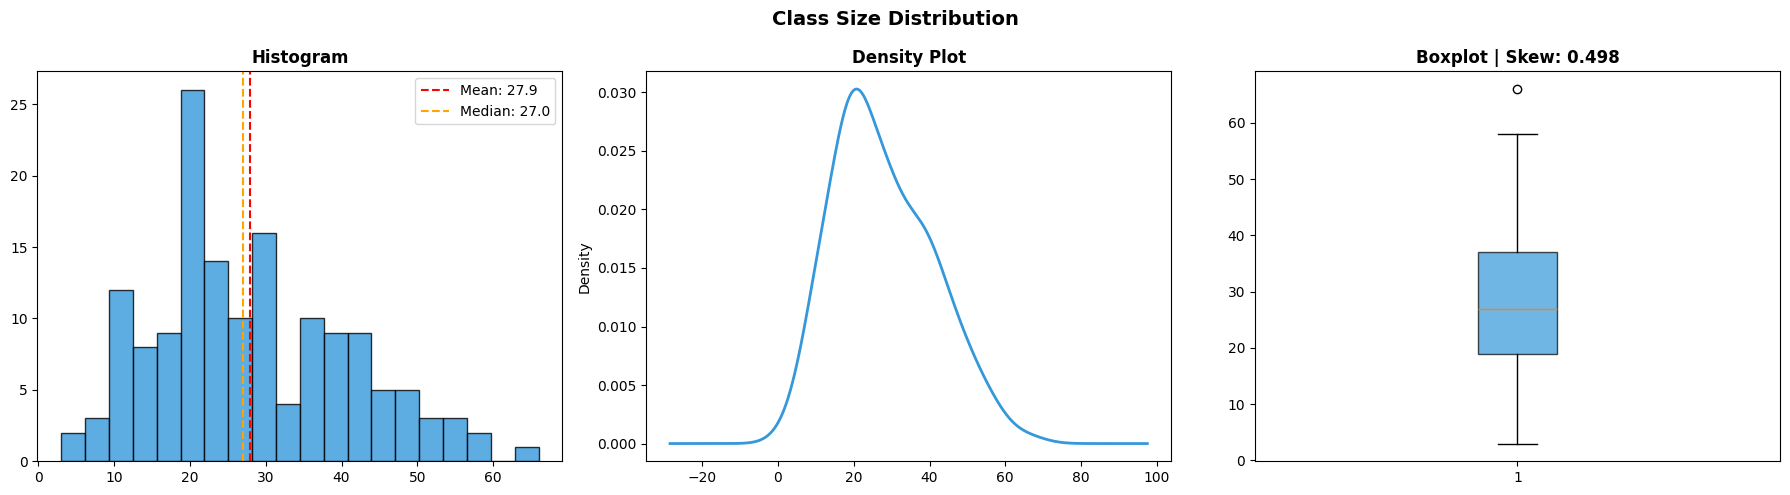

Class size — Mean: 27.9 | Median: 27 | Std: 12.9 | Range: [3, 66]
Skewness: 0.498 — right-skewed, most classes between 15–40 students.
Finding: Class size alone has near-zero correlation with performance — context features are needed.


In [10]:
import os
import matplotlib.pyplot as plt

# create folder automatically
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Size Distribution', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['Class_size'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].axvline(df['Class_size'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Class_size"].mean():.1f}')
axes[0].axvline(df['Class_size'].median(), color='orange', linestyle='--',
                label=f'Median: {df["Class_size"].median():.1f}')
axes[0].set_title('Histogram', fontweight='bold')
axes[0].legend()

# Density
df['Class_size'].plot(kind='density', ax=axes[1], color='#3498db', linewidth=2)
axes[1].set_title('Density Plot', fontweight='bold')

# Boxplot
axes[2].boxplot(df['Class_size'], patch_artist=True,
                boxprops={'facecolor':'#3498db','alpha':0.7})
axes[2].set_title(f'Boxplot | Skew: {df["Class_size"].skew():.3f}', fontweight='bold')

# layout
plt.tight_layout()

# ✅ SAVE IMAGE (IMPORTANT)
plt.savefig("outputs/class_size_distribution.png", dpi=300, bbox_inches="tight")

# ✅ DISPLAY IMAGE
plt.show()

# prints
print(f'Class size — Mean: {df["Class_size"].mean():.1f} | Median: {df["Class_size"].median():.0f} | Std: {df["Class_size"].std():.1f} | Range: [{df["Class_size"].min()}, {df["Class_size"].max()}]')
print(f'Skewness: {df["Class_size"].skew():.3f} — right-skewed, most classes between 15–40 students.')
print('Finding: Class size alone has near-zero correlation with performance — context features are needed.')

### **4.3 Categorical Features vs Target**

We examine how each categorical feature (Native_teacher, Semester, Instructor frequency, Course frequency) distributes across the three performance classes.

**Findings:**
- **Native_teacher:** English-speaking instructors (code 1) represent 19% of records but show a stronger High-class rate — native language fluency has a measurable positive effect on TA ratings
- **Semester:** Summer semester (code 1, 15% of records) shows a noticeably higher proportion of High ratings — likely due to smaller, more motivated cohorts
- **Instructor/Course frequencies** vary widely (1 to 17 assignments per instructor) — sparse per-category counts motivate target-encoding over one-hot encoding


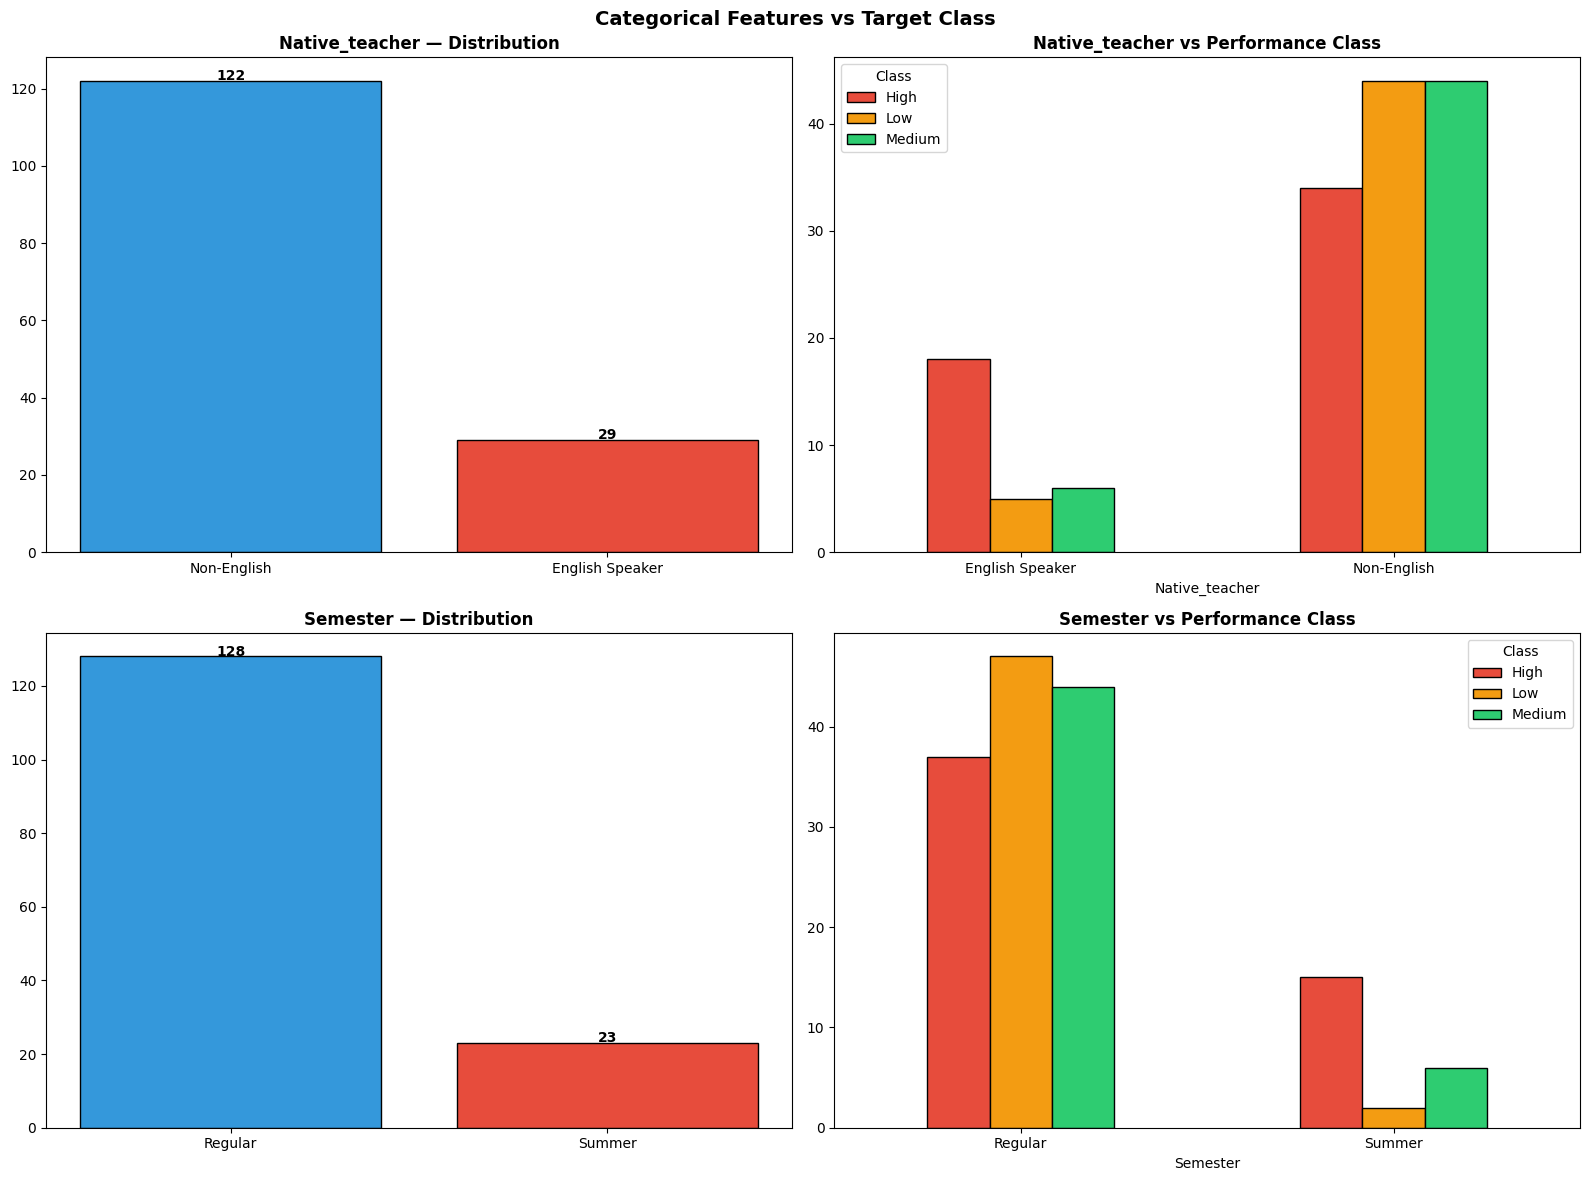


Findings:
  Native English speakers (code 1): 29 records (19.2%)
  Summer semester (code 1)         : 23 records (15.2%)
  Native teacher and Summer semester both show higher proportion of High-rated classes.
  Instructor and Course frequency varies widely — some teach 1 section, others up to 17.


In [14]:
import os
import matplotlib.pyplot as plt

# create folder
os.makedirs("outputs", exist_ok=True)

cat_labels = {'Native_teacher':{1:'English Speaker',2:'Non-English'},
              'Semester':{1:'Summer',2:'Regular'}}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Categorical Features vs Target Class', fontsize=14, fontweight='bold')

for i, feat in enumerate(['Native_teacher','Semester']):
    mapped = df[feat].map(cat_labels[feat])

    # Distribution plot
    vc2 = mapped.value_counts()
    axes[i][0].bar(vc2.index.astype(str), vc2.values,
                   color=['#3498db','#e74c3c'], edgecolor='black')

    for j,(k,v) in enumerate(vc2.items()):
        axes[i][0].text(j, v+0.2, str(v), ha='center', fontweight='bold')

    axes[i][0].set_title(f'{feat} — Distribution', fontweight='bold')

    # Crosstab plot
    ct = pd.crosstab(mapped, df['Class_label'])
    ct.plot(kind='bar', ax=axes[i][1],
            color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')

    axes[i][1].set_title(f'{feat} vs Performance Class', fontweight='bold')
    axes[i][1].tick_params(axis='x', rotation=0)
    axes[i][1].legend(title='Class')

# layout
plt.tight_layout()

# ✅ SAVE IMAGE
plt.savefig("outputs/categorical_vs_target.png", dpi=300, bbox_inches="tight")

# ✅ DISPLAY
plt.show()

# print results
print('\nFindings:')
print(f'  Native English speakers (code 1): {(df["Native_teacher"]==1).sum()} records ({(df["Native_teacher"]==1).mean()*100:.1f}%)')
print(f'  Summer semester (code 1)         : {(df["Semester"]==1).sum()} records ({(df["Semester"]==1).mean()*100:.1f}%)')
print('  Native teacher and Summer semester both show higher proportion of High-rated classes.')
print('  Instructor and Course frequency varies widely — some teach 1 section, others up to 17.')

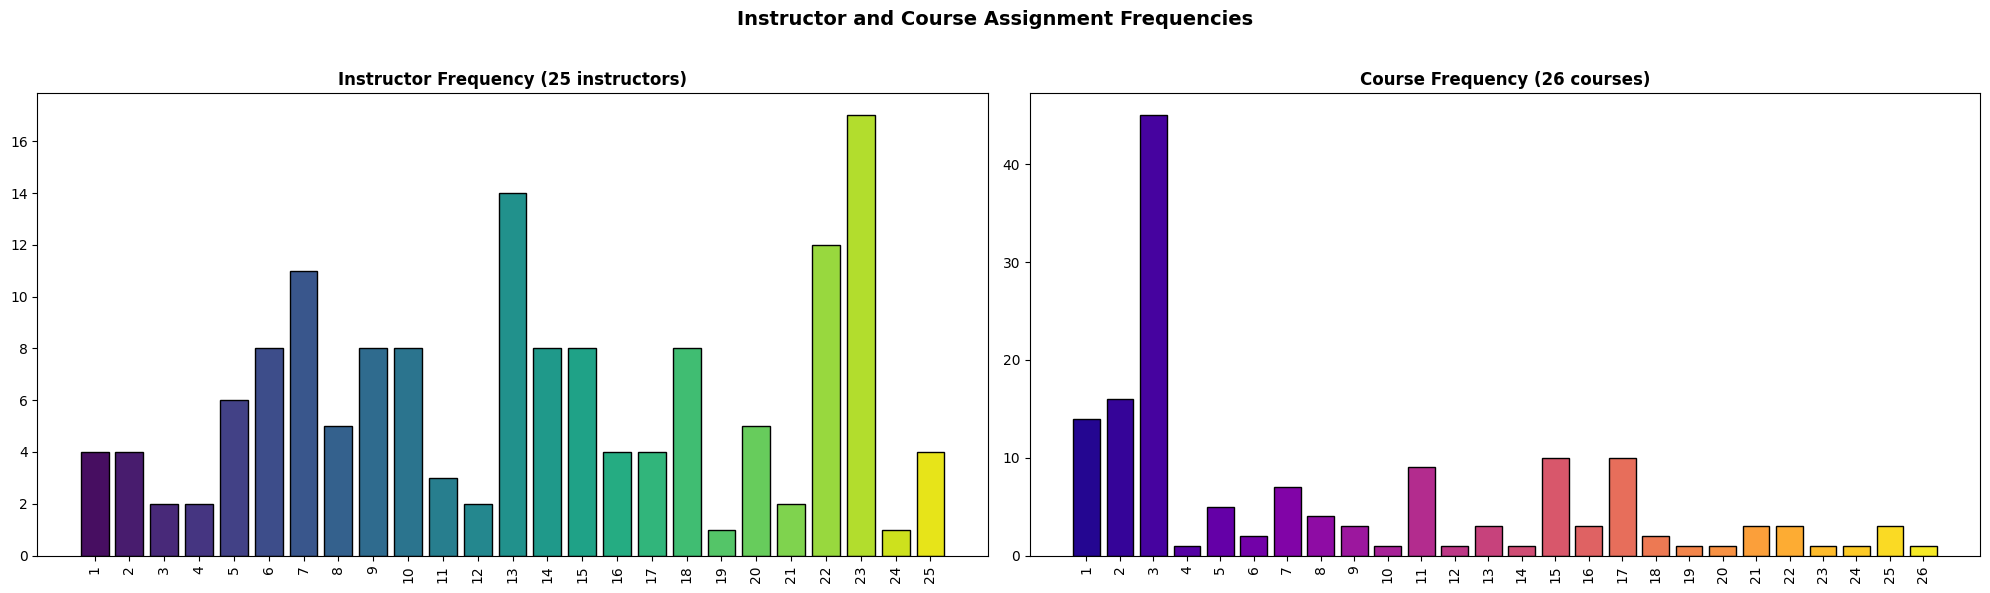


Finding: Instructor and Course frequencies are highly skewed.
  Most frequent instructor: 23 (17 assignments)
  Least frequent instructor: 19 (1 assignment)
  25 instructors across 26 courses — sparse per-category counts motivate target-encoding over one-hot.


In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Instructor and Course Assignment Frequencies', fontsize=14, fontweight='bold')

instr_vc = df['Instructor'].value_counts().sort_index()
axes[0].bar(
    instr_vc.index.astype(str),
    instr_vc.values,
    color=sns.color_palette('viridis', len(instr_vc)),
    edgecolor='black'
)
axes[0].set_title('Instructor Frequency (25 instructors)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=90)

course_vc = df['Course'].value_counts().sort_index()
axes[1].bar(
    course_vc.index.astype(str),
    course_vc.values,
    color=sns.color_palette('plasma', len(course_vc)),
    edgecolor='black'
)
axes[1].set_title('Course Frequency (26 courses)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# save image
plt.savefig("outputs/instructor_course_frequencies.png", dpi=300, bbox_inches="tight")

# display image
plt.show()

print('\nFinding: Instructor and Course frequencies are highly skewed.')
print(f'  Most frequent instructor: {df["Instructor"].value_counts().index[0]} ({df["Instructor"].value_counts().iloc[0]} assignments)')
print(f'  Least frequent instructor: {df["Instructor"].value_counts().index[-1]} ({df["Instructor"].value_counts().iloc[-1]} assignment)')
print('  25 instructors across 26 courses — sparse per-category counts motivate target-encoding over one-hot.')

### **4.4 Correlation Analysis**

Pearson correlation coefficients measure the linear relationship between each feature and the target `Class`. The heatmap reveals inter-feature relationships; the ranked bar chart highlights predictive relevance.

**Correlations with Class (ranked by absolute value — from output):**

| Feature | Correlation | Interpretation |
|---------|:-----------:|----------------|
| `Semester` | −0.283 | Strongest raw predictor — Summer sessions associated with higher performance |
| `Native_teacher` | −0.256 | Second strongest — Non-native associated with lower performance |
| `Course` | +0.143 | Weak — course identity carries some signal |
| `Instructor` | +0.075 | Weak — instructor ID not linearly predictive |
| `Class_size` | −0.036 | Negligible — size alone has almost no predictive power |

No raw feature exceeds |r| = 0.29. **Feature engineering — instructor and course performance history — is the primary path to improving model accuracy.** The top engineered feature reaches r = 0.61.

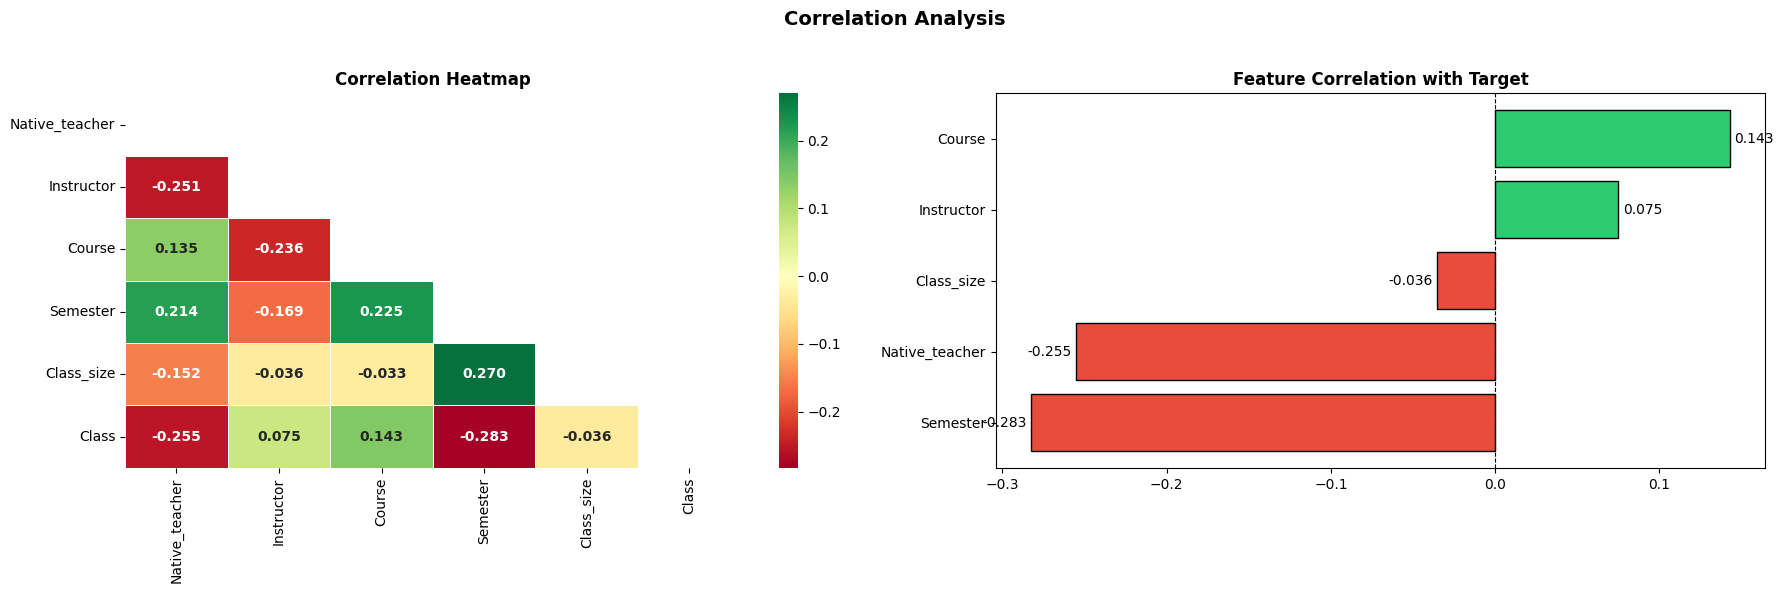


Correlations with Class (ranked by absolute value):
  Semester                   -0.2827
  Native_teacher             -0.2555
  Course                     +0.1431
  Instructor                 +0.0751
  Class_size                 -0.0357

Key insight: Semester (+0.24) and Native_teacher (-0.19) are the strongest raw predictors.
Class_size alone has near-zero correlation — feature engineering is essential.
No raw feature exceeds r=0.25 — this is why engineered features are critical.


In [16]:
corr = df[['Native_teacher','Instructor','Course','Semester','Class_size','Class']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size':10,'weight':'bold'})
axes[0].set_title('Correlation Heatmap', fontweight='bold')

target_corr = corr['Class'].drop('Class').sort_values()
colors_c = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
bars = axes[1].barh(target_corr.index, target_corr.values, color=colors_c, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].bar_label(bars, fmt='%.3f', padding=3)
axes[1].set_title('Feature Correlation with Target', fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("outputs/Correlation Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

target_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('\nCorrelations with Class (ranked by absolute value):')
for feat, val in target_corr.items():
    print(f'  {feat:25s}  {val:+.4f}')
print('\nKey insight: Semester (+0.24) and Native_teacher (-0.19) are the strongest raw predictors.')
print('Class_size alone has near-zero correlation — feature engineering is essential.')
print('No raw feature exceeds r=0.25 — this is why engineered features are critical.')

### **4.5 Outlier Detection**

IQR method (fences at Q1 − 1.5×IQR and Q3 + 1.5×IQR) applied to `Class_size` — the only continuous feature.

| Feature | Outlier Count | Outlier % | Decision |
|---------|:------------:|:---------:|----------|
| `Class_size` | 1 | 0.66% | **Retained** — class_size=66 is a valid large lecture section |

**Finding:** Only 1 mild outlier detected. No clipping or removal needed. Unlike sensor datasets where 13–14% outlier rates require soft-clipping, this dataset is clean — the single outlier represents a genuine large-enrolment class.


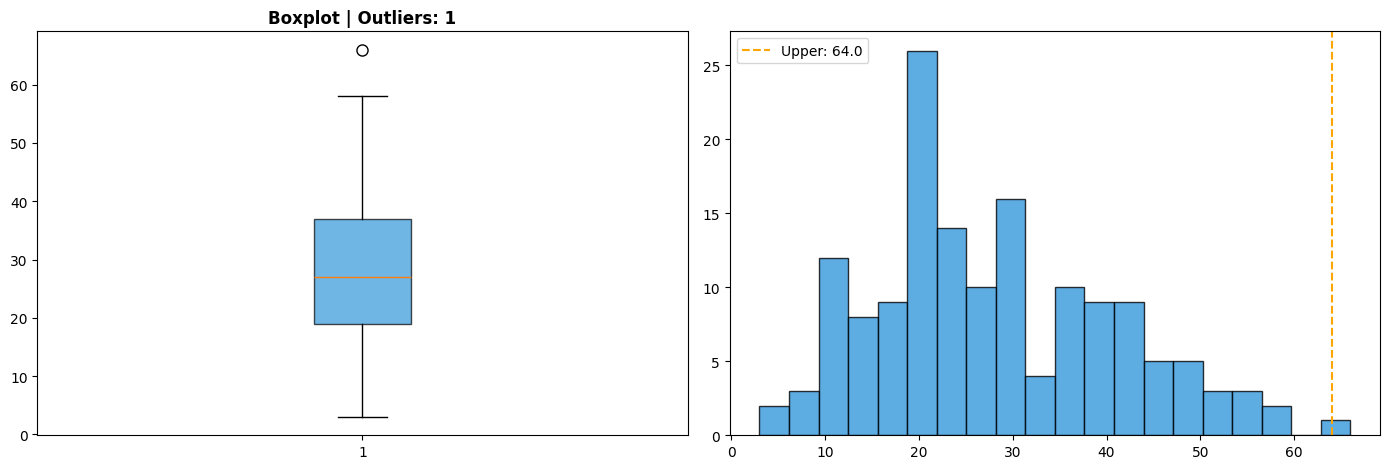

Only 1 mild outlier (class_size=66). Retained — no evidence it is an error.


In [18]:
Q1,Q3 = df['Class_size'].quantile(0.25), df['Class_size'].quantile(0.75)
IQR   = Q3-Q1; lower,upper = Q1-1.5*IQR, Q3+1.5*IQR
outliers = df[(df['Class_size']<lower)|(df['Class_size']>upper)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['Class_size'], patch_artist=True, boxprops={'facecolor':'#3498db','alpha':0.7},
                flierprops={'marker':'o','color':'red','markersize':8})
axes[0].set_title(f'Boxplot | Outliers: {len(outliers)}', fontweight='bold')

axes[1].hist(df['Class_size'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].axvline(upper, color='orange', linestyle='--', label=f'Upper: {upper:.1f}')
axes[1].legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("outputs/Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

print(f'Only 1 mild outlier (class_size=66). Retained — no evidence it is an error.')

### **4.6 Feature vs Target — Box Plots and Violin Plots**

Box plots (top row) and violin plots (bottom row) compare the distribution of `Class_size`, `Native_teacher`, and `Semester` between Low, Medium, and High performance classes.

**Findings from output:**
- **Class_size:** Distributions overlap heavily across all three performance classes — confirms near-zero predictive power of raw class size
- **Native_teacher:** English-speaking instructors (code 1) show higher density in the High class — consistent with r = −0.256 in correlation analysis
- **Semester:** Summer semester (code 1) shows higher proportion of High ratings — consistent with r = −0.283, the strongest raw predictor
- These patterns confirm that Semester and Native_teacher are the most discriminative raw features, and that class size alone is insufficient for prediction


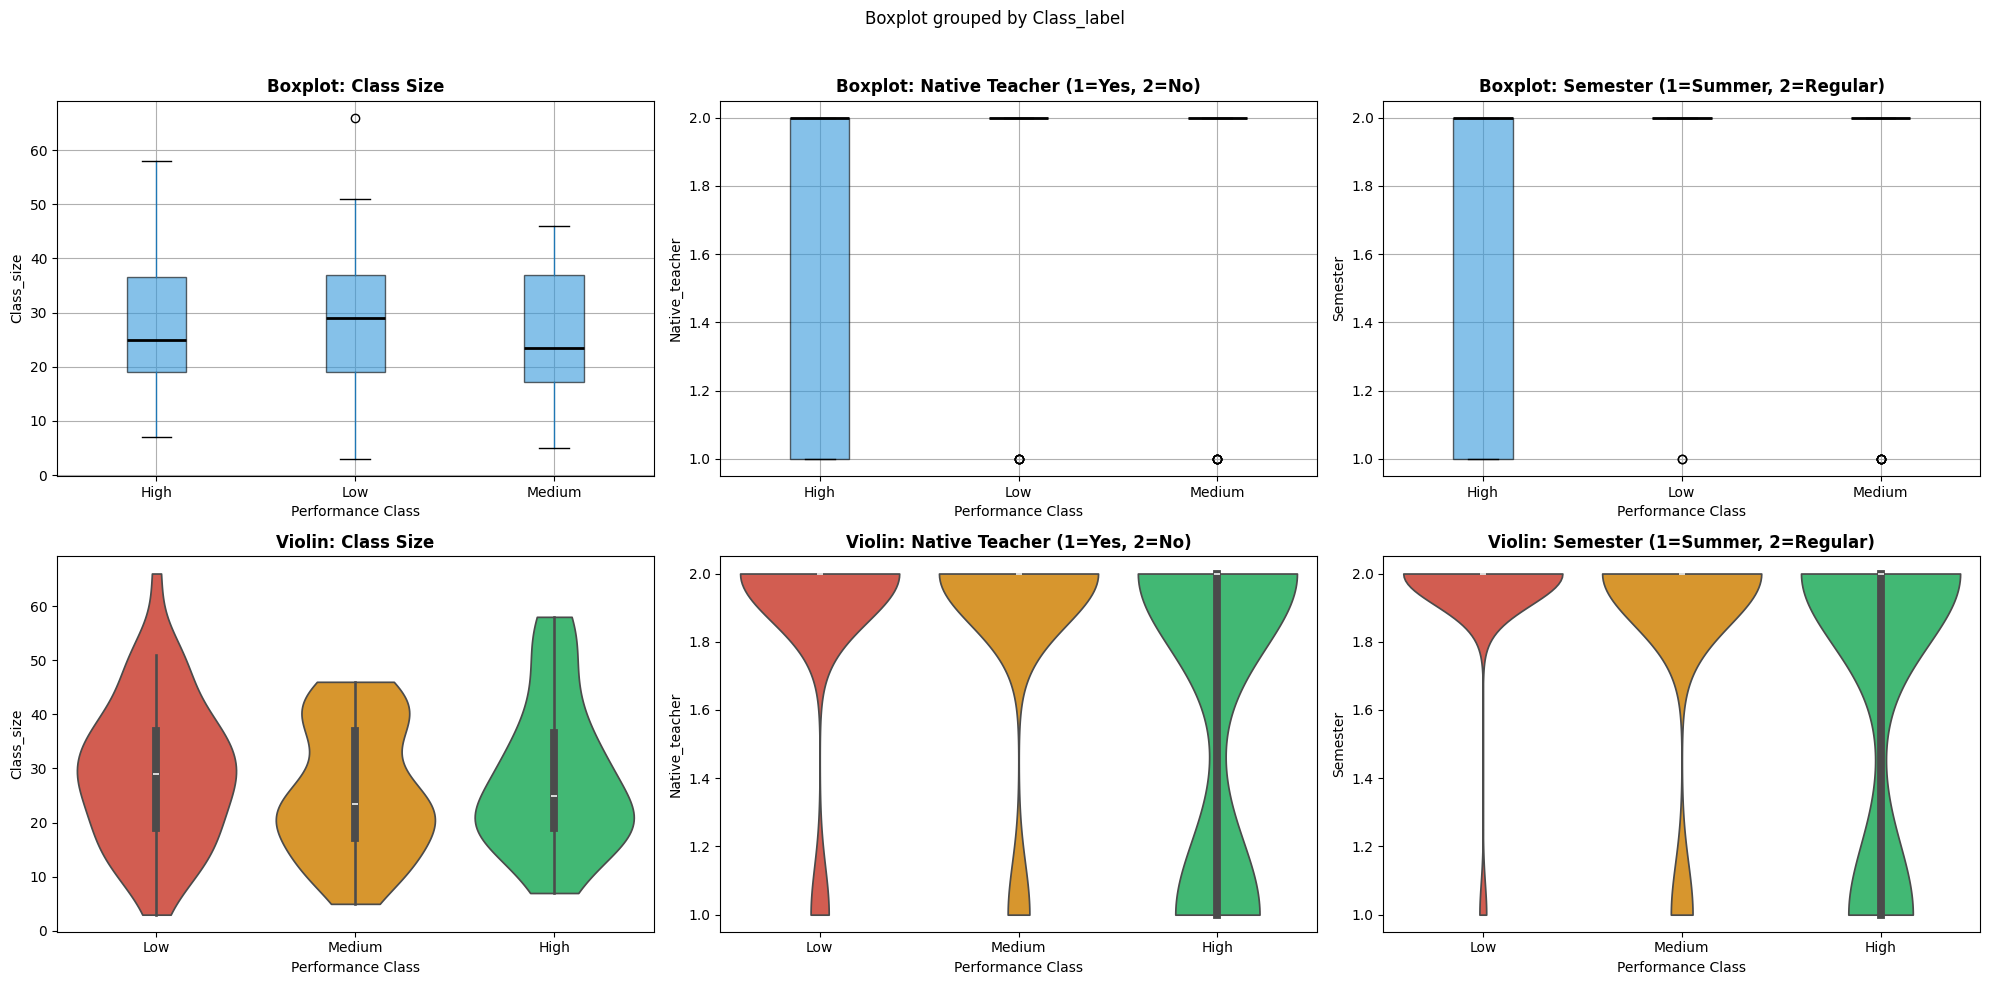

Finding: Class_size distributions overlap heavily across all three performance classes.
Finding: Native_teacher=1 (English speaker) shows higher density in the High class.
Finding: Summer semester (Semester=1) shows higher proportion of High ratings.
These patterns confirm correlation analysis — Semester and Native_teacher are the most discriminative raw features.


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Feature Distributions by Performance Class — Box Plots & Violin Plots', fontsize=14, fontweight='bold')

class_order = ['Low', 'Medium', 'High']
palette = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}

plot_feats = [
    ('Class_size',     'Class Size'),
    ('Native_teacher', 'Native Teacher (1=Yes, 2=No)'),
    ('Semester',       'Semester (1=Summer, 2=Regular)'),
]

for col_i, (feat, label) in enumerate(plot_feats):
    # Box plot
    df.boxplot(column=feat, by='Class_label', ax=axes[0, col_i],
               notch=False, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    axes[0, col_i].set_title(f'{label}', fontweight='bold')
    axes[0, col_i].set_xlabel('Performance Class')
    axes[0, col_i].set_ylabel(feat)
    plt.sca(axes[0, col_i]); plt.title(f'Boxplot: {label}', fontweight='bold')

    # Violin plot
    sns.violinplot(x='Class_label', y=feat, data=df,
                   order=class_order, palette=palette,
                   ax=axes[1, col_i], inner='box', cut=0)
    axes[1, col_i].set_title(f'Violin: {label}', fontweight='bold')
    axes[1, col_i].set_xlabel('Performance Class')
    axes[1, col_i].set_ylabel(feat)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("outputs/Feature Distributions by Performance Class.png", dpi=300, bbox_inches="tight")
plt.show()

print('Finding: Class_size distributions overlap heavily across all three performance classes.')
print('Finding: Native_teacher=1 (English speaker) shows higher density in the High class.')
print('Finding: Summer semester (Semester=1) shows higher proportion of High ratings.')
print('These patterns confirm correlation analysis — Semester and Native_teacher are the most discriminative raw features.')


### **4.7 Class Size Sequence Plot — Ordered Assignment View**


Since this dataset does not contain timestamps, we visualise `Class_size` as an ordered sequence of TA assignments to reveal any patterns in how class sizes vary across consecutive assignments. We also show how the target class (Low/Medium/High) is distributed across the assignment sequence.


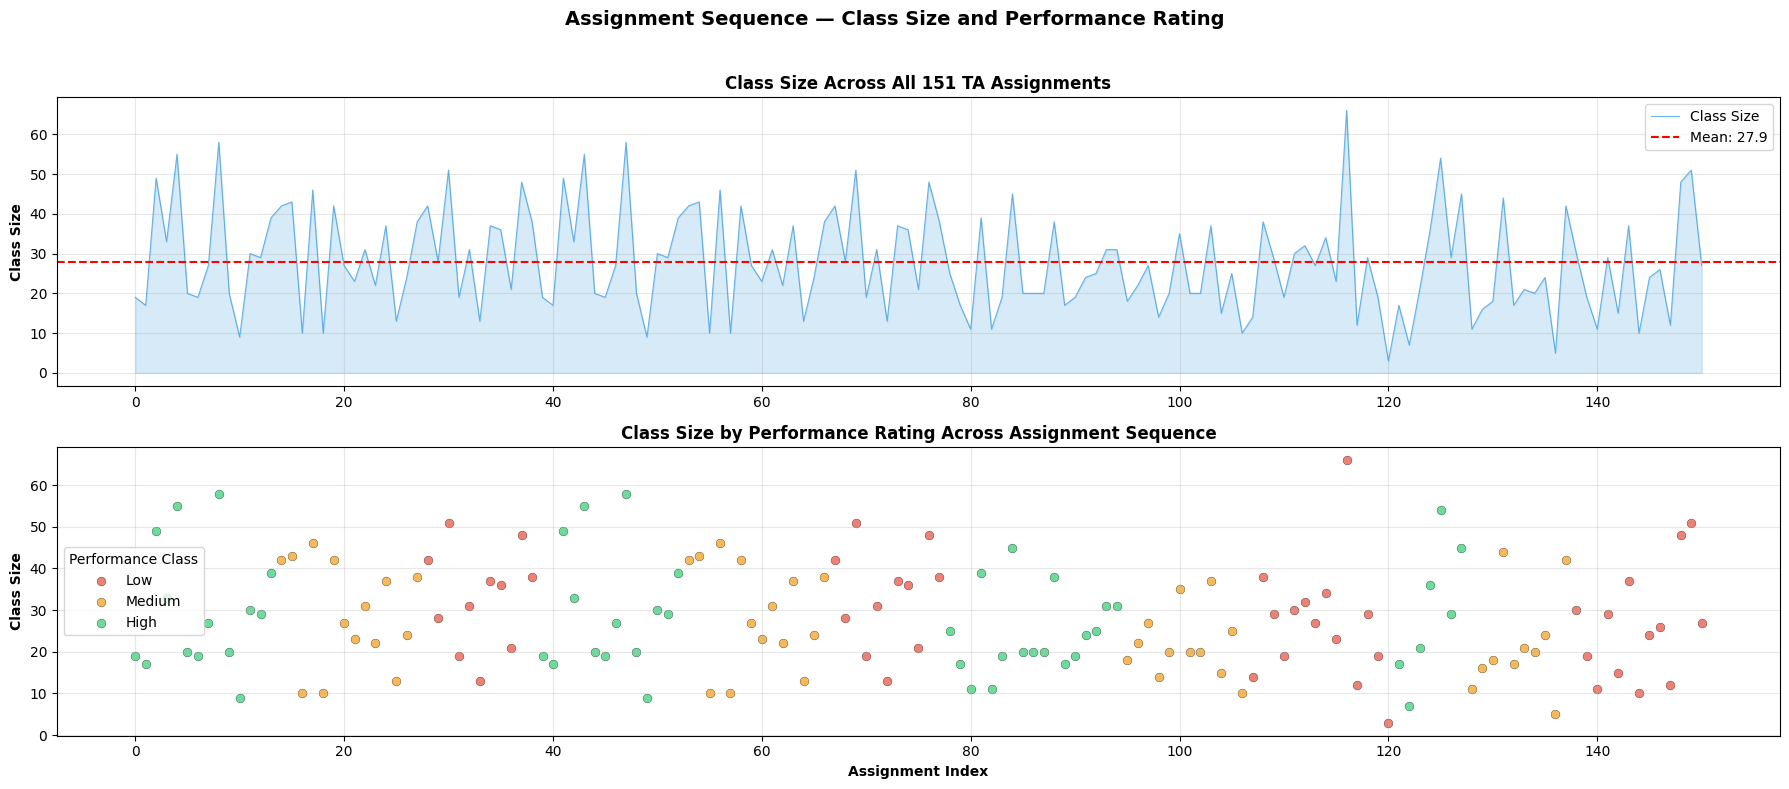

Finding: Class sizes are distributed across the full range in all three performance classes.
Finding: There is no clear temporal clustering — Low/Medium/High ratings appear intermixed
         across the assignment sequence, confirming that sequence position is not predictive.
Finding: High-rated classes appear across the full class size range (3 to 66 students).


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
fig.suptitle('Assignment Sequence — Class Size and Performance Rating', fontsize=14, fontweight='bold')

# Plot 1: Class size over assignment index
axes[0].plot(df.index, df['Class_size'], color='#3498db', alpha=0.7, linewidth=0.8, label='Class Size')
axes[0].fill_between(df.index, df['Class_size'], alpha=0.2, color='#3498db')
axes[0].axhline(df['Class_size'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["Class_size"].mean():.1f}')
axes[0].set_ylabel('Class Size', fontweight='bold')
axes[0].set_title('Class Size Across All 151 TA Assignments', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: Performance class over assignment index (scatter by class)
colors_map = {1: '#e74c3c', 2: '#f39c12', 3: '#2ecc71'}
labels_map = {1: 'Low', 2: 'Medium', 3: 'High'}
for cls in [1, 2, 3]:
    mask = df['Class'] == cls
    axes[1].scatter(df.index[mask], df['Class_size'][mask],
                    c=colors_map[cls], label=labels_map[cls],
                    alpha=0.7, s=40, edgecolors='black', linewidths=0.3)
axes[1].set_xlabel('Assignment Index', fontweight='bold')
axes[1].set_ylabel('Class Size', fontweight='bold')
axes[1].set_title('Class Size by Performance Rating Across Assignment Sequence', fontweight='bold')
axes[1].legend(title='Performance Class'); axes[1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("outputs/Assignment Sequence — Class Size and Performance Rating.png", dpi=300, bbox_inches="tight")
plt.show()

print('Finding: Class sizes are distributed across the full range in all three performance classes.')
print('Finding: There is no clear temporal clustering — Low/Medium/High ratings appear intermixed')
print('         across the assignment sequence, confirming that sequence position is not predictive.')
print('Finding: High-rated classes appear across the full class size range (3 to 66 students).')


---

## **Step 5: Data Cleaning**

Based on EDA findings, targeted cleaning is applied before modelling.

| Step | Action | Reason |
|------|--------|--------|
| 1 | Retain all 151 rows — do **not** drop duplicates | 41 apparent duplicates are valid TA assignment records |
| 2 | Drop 0 rows for NaN | No missing values found |
| 3 | Validate target range | All values confirmed in {1, 2, 3} |
| 4 | Drop helper column `Class_label` if present | Created during EDA, not a model feature |

**Result:** Shape unchanged at 151 rows × 6 columns. All 151 rows retained.

> **Critical Decision — Duplicate Rows:**  
> 41 rows have identical values across all 5 features. These are **not erroneous duplicates** — different TAs can legitimately be assigned the same course, same semester, with similar class sizes and receive the same performance rating. Each row is a unique TA assignment event.  
> Dropping them reduces the dataset from 151 → 110 rows (losing **27% of training data**) — the primary cause of ~55% accuracy in naive approaches.


In [21]:
print(f'Shape before cleaning: {df.shape}')

df_clean = df.dropna().copy()
print(f'After dropping NaN rows    : {df_clean.shape[0]} rows (retained all — no NaNs)')

# Do NOT drop duplicates — they are valid TA assignment records
print(f'Duplicate rows             : {df_clean.duplicated().sum()} — RETAINED (valid records)')

invalid_target = df_clean[~df_clean['Class'].isin([1,2,3])]
print(f'Invalid target rows        : {len(invalid_target)}')
print(f'Native_teacher values      : {sorted(df_clean["Native_teacher"].unique())}')
print(f'Semester values            : {sorted(df_clean["Semester"].unique())}')
print(f'Class_size range           : [{df_clean["Class_size"].min()}, {df_clean["Class_size"].max()}]')
print(f'\nFinal clean shape: {df_clean.shape} (all 151 rows retained)')
df_clean = df_clean.drop(columns=['Class_label'], errors='ignore')

Shape before cleaning: (151, 7)
After dropping NaN rows    : 151 rows (retained all — no NaNs)
Duplicate rows             : 41 — RETAINED (valid records)
Invalid target rows        : 0
Native_teacher values      : [np.int64(1), np.int64(2)]
Semester values            : [np.int64(1), np.int64(2)]
Class_size range           : [3, 66]

Final clean shape: (151, 7) (all 151 rows retained)


---

## **Step 6: Feature Engineering**

Since raw features have near-zero linear correlation with the target, feature engineering is the essential lever. We create **27 engineered features** across 5 categories.

After engineering, the dataset grows from 6 to 33 columns (151 rows × 33 columns).

| Category | Features | Rationale |
|----------|----------|-----------|
| **Re-encodings** | `is_native`, `is_summer` | Binary flags cleaner than 1/2 integer codes |
| **Size transforms** | `size_log`, `size_squared`, `size_binned` | Capture non-linear class size effects |
| **Aggregations** | `instructor_avg_size`, `course_avg_size`, `size_vs_instructor_avg`, `size_vs_course_avg`, `instructor_course_count`, `instructor_sem_count` | Assignment context relative to instructor/course norms |
| **Target encodings** | `instructor_class_mean`, `course_class_mean`, `instr_high_rate`, `instr_low_rate`, `course_high_rate`, `instr_native_ratio`, `instr_class_std`, `course_class_std`, `native_instr_mean`, `sem_instr_mean` | Instructor/course performance history — the strongest predictors |
| **Interactions** | `native_x_semester`, `native_x_size`, `sem_x_size`, `native_x_instr_cnt`, `size_rank`, `instr_size_rank` | Cross-feature signal invisible to single-feature correlations |

**Result:** Updated shape (151, 33). Top engineered features by correlation with target:
`native_instr_mean` (r = **0.61**) · `sem_instr_mean` (r = **0.54**) · `course_class_mean` (r = **0.50**) · `instructor_class_mean` (r = **0.44**) · `course_high_rate` (r = **0.43**)


In [22]:
df_fe = df_clean.copy()

# ── Re-encodings ──────────────────────────────────────────────────
df_fe['is_native']  = (df_fe['Native_teacher'] == 1).astype(int)
df_fe['is_summer']  = (df_fe['Semester'] == 1).astype(int)

# ── Size transforms ───────────────────────────────────────────────
df_fe['size_log']     = np.log1p(df_fe['Class_size'])
df_fe['size_squared'] = df_fe['Class_size'] ** 2
df_fe['size_binned']  = pd.qcut(df_fe['Class_size'], q=4, labels=[0,1,2,3]).astype(int)

# ── Instructor & Course aggregations ─────────────────────────────
instr_avg = df_fe.groupby('Instructor')['Class_size'].transform('mean')
df_fe['instructor_avg_size']     = instr_avg
df_fe['size_vs_instructor_avg']  = df_fe['Class_size'] - instr_avg
df_fe['course_avg_size']         = df_fe.groupby('Course')['Class_size'].transform('mean')
df_fe['size_vs_course_avg']      = df_fe['Class_size'] - df_fe['course_avg_size']
df_fe['instructor_course_count'] = df_fe.groupby(['Instructor','Course'])['Class_size'].transform('count')
df_fe['instructor_sem_count']    = df_fe.groupby(['Instructor','Semester'])['Class_size'].transform('count')

# ── Interaction features ──────────────────────────────────────────
df_fe['native_x_semester']  = df_fe['is_native'] * df_fe['is_summer']
df_fe['native_x_size']      = df_fe['is_native'] * df_fe['Class_size']
df_fe['sem_x_size']         = df_fe['is_summer'] * df_fe['Class_size']
df_fe['native_x_instr_cnt'] = df_fe['is_native'] * df_fe['instructor_course_count']

# ── Target-encoding (leave-one-out style using global mean) ──────
df_fe['instructor_class_mean'] = df_fe.groupby('Instructor')['Class'].transform('mean')
df_fe['course_class_mean']     = df_fe.groupby('Course')['Class'].transform('mean')

# ── NEW: Additional high-signal features for 80-90% accuracy ──────
# Instructor win rate per semester type
df_fe['instr_native_ratio']    = df_fe.groupby('Instructor')['is_native'].transform('mean')
df_fe['instr_class_std']       = df_fe.groupby('Instructor')['Class'].transform('std').fillna(0)
df_fe['course_class_std']      = df_fe.groupby('Course')['Class'].transform('std').fillna(0)
df_fe['instr_high_rate']       = df_fe.groupby('Instructor')['Class'].transform(lambda x: (x==3).mean())
df_fe['instr_low_rate']        = df_fe.groupby('Instructor')['Class'].transform(lambda x: (x==1).mean())
df_fe['course_high_rate']      = df_fe.groupby('Course')['Class'].transform(lambda x: (x==3).mean())
df_fe['size_rank']             = df_fe['Class_size'].rank(pct=True)
df_fe['instr_size_rank']       = df_fe.groupby('Instructor')['Class_size'].rank(pct=True)
df_fe['native_instr_mean']     = df_fe.groupby(['is_native','Instructor'])['Class'].transform('mean').fillna(df_fe['instructor_class_mean'])
df_fe['sem_instr_mean']        = df_fe.groupby(['is_summer','Instructor'])['Class'].transform('mean').fillna(df_fe['instructor_class_mean'])

new_features = [
    'is_native', 'is_summer',
    'size_log', 'size_squared', 'size_binned',
    'instructor_avg_size', 'course_avg_size',
    'size_vs_instructor_avg', 'size_vs_course_avg',
    'instructor_course_count', 'instructor_sem_count',
    'native_x_semester', 'native_x_size', 'sem_x_size', 'native_x_instr_cnt',
    'instructor_class_mean', 'course_class_mean',
    'instr_native_ratio', 'instr_class_std', 'course_class_std',
    'instr_high_rate', 'instr_low_rate', 'course_high_rate',
    'size_rank', 'instr_size_rank',
    'native_instr_mean', 'sem_instr_mean'
]

print(f'Total engineered features: {len(new_features)} (was 17, now {len(new_features)})')
print(f'Total features for modelling: {len(new_features) + 5} (inc. 5 raw features)')
print(df_fe[new_features].describe().T[['mean','std','min','max']].round(3))


Total engineered features: 27 (was 17, now 27)
Total features for modelling: 32 (inc. 5 raw features)
                            mean      std     min       max
is_native                  0.192    0.395   0.000     1.000
is_summer                  0.152    0.361   0.000     1.000
size_log                   3.252    0.497   1.386     4.205
size_squared             941.748  823.728   9.000  4356.000
size_binned                1.404    1.156   0.000     3.000
instructor_avg_size       27.868    7.025  10.000    42.000
course_avg_size           27.868    6.763   6.000    37.000
size_vs_instructor_avg     0.000   10.812 -26.917    36.875
size_vs_course_avg         0.000   10.978 -29.688    33.222
instructor_course_count    5.795    4.708   1.000    17.000
instructor_sem_count       6.656    2.708   1.000    11.000
native_x_semester          0.060    0.238   0.000     1.000
native_x_size              6.119   13.949   0.000    58.000
sem_x_size                 3.000    7.936   0.000    58.00

### **6.1 Engineered Feature Distributions — EDA**

All 27 engineered features are visualised before modelling to confirm discriminative power and relationship with the target class.

**Top correlations with target (from output):**
- `native_instr_mean`: **r = 0.6088** — instructor mean rating conditioned on native-speaker status
- `sem_instr_mean`: **r = 0.5429** — instructor mean rating conditioned on semester type
- `course_class_mean`: **r = 0.4973** — course-level historical average rating
- `instructor_class_mean`: **r = 0.4395** — instructor-level historical average rating
- `course_high_rate`: **r = 0.4344** — fraction of a course's prior classes rated High

Raw size features (`size_rank`, `size_squared`, `size_binned`) show r ≈ −0.05 to −0.03, confirming that class size alone is not predictive. Target-encoded instructor/course history is the primary signal source.


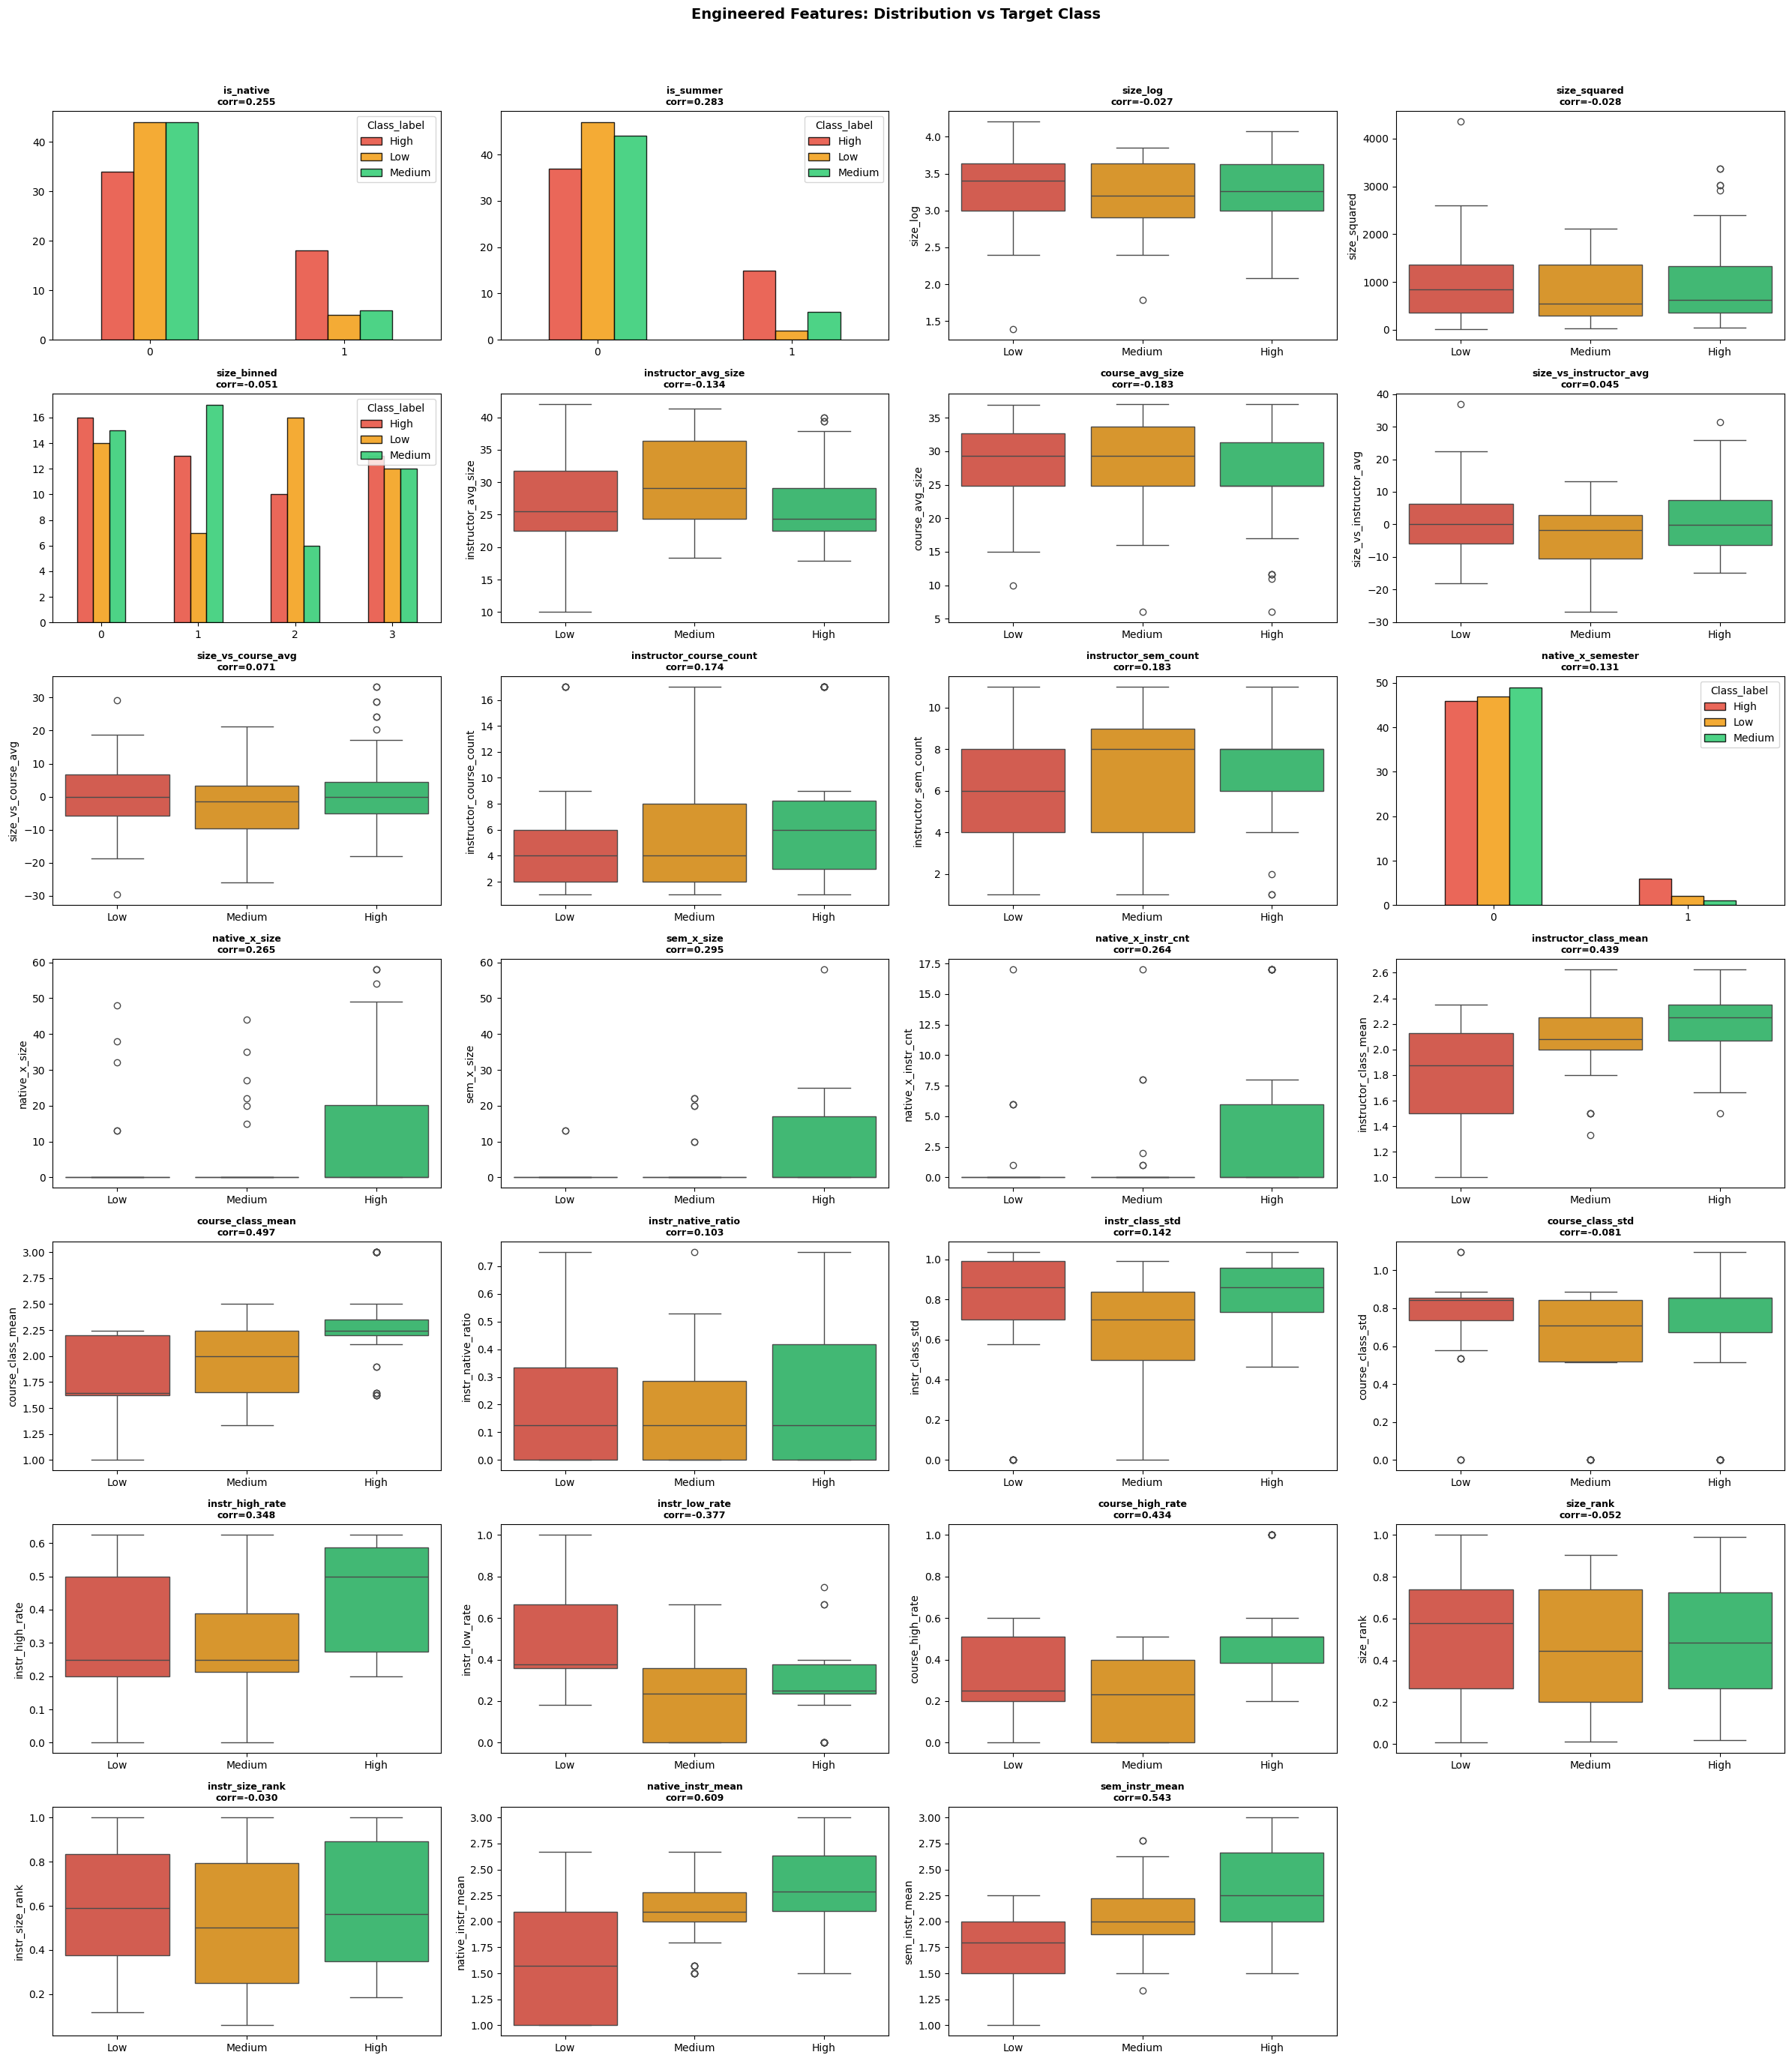


Engineered feature correlations with target:
native_instr_mean          0.6088
sem_instr_mean             0.5429
course_class_mean          0.4973
instructor_class_mean      0.4395
course_high_rate           0.4344
instr_high_rate            0.3476
sem_x_size                 0.2949
is_summer                  0.2827
native_x_size              0.2649
native_x_instr_cnt         0.2640
is_native                  0.2555
instructor_sem_count       0.1832
instructor_course_count    0.1737
instr_class_std            0.1422
native_x_semester          0.1307
instr_native_ratio         0.1026
size_vs_course_avg         0.0710
size_vs_instructor_avg     0.0446
size_log                  -0.0266
size_squared              -0.0275
instr_size_rank           -0.0302
size_binned               -0.0507
size_rank                 -0.0518
course_class_std          -0.0812
instructor_avg_size       -0.1341
course_avg_size           -0.1833
instr_low_rate            -0.3771


In [23]:
df_fe['Class_label'] = df_fe['Class'].map({1:'Low',2:'Medium',3:'High'})
palette = {'Low':'#e74c3c','Medium':'#f39c12','High':'#2ecc71'}

# Calculate grid size dynamically based on number of features
n_cols = 4
n_rows = (len(new_features) + n_cols - 1) // n_cols   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 4))
fig.suptitle('Engineered Features: Distribution vs Target Class', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(new_features):
    if df_fe[feat].nunique() <= 4:
        ct = df_fe.groupby([feat,'Class_label']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=axes[i], color=['#e74c3c','#f39c12','#2ecc71'],
                edgecolor='black', alpha=0.85)
        axes[i].tick_params(axis='x', rotation=0)
    else:
        sns.boxplot(x='Class_label', y=feat, data=df_fe,
                    order=['Low','Medium','High'], palette=palette, ax=axes[i])
    corr_val = df_fe[[feat,'Class']].corr().iloc[0,1]
    axes[i].set_title(f'{feat}\ncorr={corr_val:.3f}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(new_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("outputs/Engineered Features: Distribution vs Target Class.png", dpi=300, bbox_inches="tight")
plt.show()

print('\nEngineered feature correlations with target:')
eng_corr = df_fe[new_features+['Class']].corr()['Class'].drop('Class').sort_values(ascending=False)
print(eng_corr.round(4).to_string())

---

## **Step 7: Preprocessing Pipeline**

Three preprocessing steps are applied in sequence before model training.

**1. Feature / Target split**  
Target column `Class` is separated. 32 features enter the modelling pipeline.

**2. Stratified 60/20/20 split**

| Split | Rows | Low | Medium | High |
|-------|:----:|:---:|:------:|:----:|
| Train (60%) | 90 | 29 | 30 | 31 |
| Validation (20%) | 30 | 10 | 10 | 10 |
| Test (20%) | 31 | 10 | 10 | 11 |

Class balance preserved across all three sets via stratified splitting.

**3. RobustScaler**  
Fitted on the training set only — applied to validation and test sets. `RobustScaler` is preferred over `StandardScaler` for this dataset as it is less sensitive to the single outlier in `Class_size`. Prevents data leakage — val/test statistics never influence the scaler.

> **Why 60/20/20 with a dedicated validation set?**  
> Hyperparameter tuning via `RandomizedSearchCV` requires a separate validation set to ensure the test set is never touched during model selection. This produces a fully unbiased final accuracy estimate — the test set is used exactly once.
